In [1]:
library(dplyr)
library(tidyr)

Warning message:
“程辑包‘dplyr’是用R版本4.3.2 来建造的”

载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
data <- read.csv(paste0(indir,"/03-5hmC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv"), stringsAsFactors = FALSE,check.names = F)
head(data);dim(data)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,⋯,Lamp5 Gaba_compartment,Pvalb Gaba_compartment,Sst Gaba_compartment,STR D1 Gaba_compartment,STR D2 Gaba_compartment,ACB-BST-FS D1 Gaba_compartment,Astro-TE NN_compartment,Oligo NN_compartment,OPC NN_compartment,Microglia NN_compartment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,


[1] 24639    60

In [3]:
table(data$`L2/3 IT CTX Glut_compartment`)


          A     B 
 1501 12032 11106 

In [4]:
label_columns <- grep("_compartment$", names(data), value = TRUE)
label_columns

[1] "L2/3 IT CTX Glut_compartment"      "L4/5 IT CTX Glut_compartment"     
 [3] "L5 IT CTX Glut_compartment"        "L2/3 IT RSP Glut_compartment"     
 [5] "L4 RSP-ACA Glut_compartment"       "L5 ET CTX Glut_compartment"       
 [7] "SUB-ProS Glut_compartment"         "CA1-ProS Glut_compartment"        
 [9] "CA3 Glut_compartment"              "CLA-EPd-CTX Car3 Glut_compartment"
[11] "L5 NP CTX Glut_compartment"        "L6 CT CTX Glut_compartment"       
[13] "DG Glut_compartment"               "OB Eomes Ms4a15 Glut_compartment" 
[15] "OB-in Frmd7 Gaba_compartment"      "OB-out Frmd7 Gaba_compartment"    
[17] "OB Dopa-Gaba_compartment"          "OB-STR-CTX Inh IMN_compartment"   
[19] "Sncg Gaba_compartment"             "Lamp5 Gaba_compartment"           
[21] "Pvalb Gaba_compartment"            "Sst Gaba_compartment"             
[23] "STR D1 Gaba_compartment"           "STR D2 Gaba_compartment"          
[25] "ACB-BST-FS D1 Gaba_compartment"    "Astro-TE NN_compartment"          
[27] "Oligo NN_compartment"              "OPC NN_compartment"               
[29] "Microglia NN_compartment"

In [5]:
length(label_columns)

[1] 29

In [6]:
mean_results <- data.frame()

In [7]:
mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

for (label_col in label_columns) {

  main_col <- sub("_compartment$", "", label_col)

  if (main_col %in% names(data)) {

    mean_values <- data %>%
      filter(!is.na(.data[[label_col]])) %>%
      group_by(.data[[label_col]]) %>%
      summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
      pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

    A_mean <- mean_values[[paste0(main_col, "_A")]]
    B_mean <- mean_values[[paste0(main_col, "_B")]]

    subclass_results <- data.frame(
      Subclass = main_col,
      A_mean = A_mean,
      B_mean = B_mean,
      stringsAsFactors = FALSE
    )

    mean_results <- rbind(mean_results, subclass_results)
  } else {
    warning(paste("Main column not found for label column:", label_col))
  }
}

Warning message:
“Use of .data in tidyselect expressions was deprecated in tidyselect 1.2.0.
ℹ Please use `all_of(var)` (or `any_of(var)`) instead of `.data[[var]]`”


In [8]:
mean_results

Subclass,A_mean,B_mean
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,0.25583359,0.25101428
L4/5 IT CTX Glut,0.25418486,0.23761872
L5 IT CTX Glut,0.27981829,0.25258462
L2/3 IT RSP Glut,0.28369207,0.25610792
L4 RSP-ACA Glut,0.30476724,0.28112498
L5 ET CTX Glut,0.29060479,0.28464085
SUB-ProS Glut,0.27000429,0.25170588
CA1-ProS Glut,0.23956269,0.22802431
CA3 Glut,0.24748933,0.23050754


In [9]:
mean_results <- mean_results %>%
  mutate(
    logFC = log2(A_mean / B_mean)
  )

mean_results

Subclass,A_mean,B_mean,logFC
<chr>,<dbl>,<dbl>,<dbl>
L2/3 IT CTX Glut,0.25583359,0.25101428,0.02743624
L4/5 IT CTX Glut,0.25418486,0.23761872,0.09722956
L5 IT CTX Glut,0.27981829,0.25258462,0.14772349
L2/3 IT RSP Glut,0.28369207,0.25610792,0.14757394
L4 RSP-ACA Glut,0.30476724,0.28112498,0.11649619
L5 ET CTX Glut,0.29060479,0.28464085,0.02991574
SUB-ProS Glut,0.27000429,0.25170588,0.10124343
CA1-ProS Glut,0.23956269,0.22802431,0.07121561
CA3 Glut,0.24748933,0.23050754,0.10255233


In [10]:
# mean_results$diff <- mean_results$A_mean - mean_results$B_mean
# mean_results

In [11]:
subclass <- c('L2/3 IT CTX Glut','L4/5 IT CTX Glut','L5 IT CTX Glut','L2/3 IT RSP Glut','L4 RSP-ACA Glut','L5 ET CTX Glut','SUB-ProS Glut','CA1-ProS Glut','CA3 Glut',
           'CLA-EPd-CTX Car3 Glut','L5 NP CTX Glut','L6 CT CTX Glut','DG Glut','OB Eomes Ms4a15 Glut','OB-in Frmd7 Gaba','OB-out Frmd7 Gaba','OB Dopa-Gaba',
           'OB-STR-CTX Inh IMN','Sncg Gaba','Lamp5 Gaba','Pvalb Gaba','Sst Gaba','STR D1 Gaba','STR D2 Gaba','ACB-BST-FS D1 Gaba','Astro-TE NN','Oligo NN',
           'OPC NN','Microglia NN')

subclass

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"       "L5 ET CTX Glut"       
 [7] "SUB-ProS Glut"         "CA1-ProS Glut"         "CA3 Glut"             
[10] "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"        "L6 CT CTX Glut"       
[13] "DG Glut"               "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[16] "OB-out Frmd7 Gaba"     "OB Dopa-Gaba"          "OB-STR-CTX Inh IMN"   
[19] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[22] "Sst Gaba"              "STR D1 Gaba"           "STR D2 Gaba"          
[25] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[28] "OPC NN"                "Microglia NN"

In [12]:
mean_results$Subclass <- factor(mean_results$Subclass, levels = subclass)

In [13]:
mean_results$color_flag <- ifelse(mean_results$logFC > 0, "positive", "negative")

In [14]:
mean_results

Subclass,A_mean,B_mean,logFC,color_flag
<fct>,<dbl>,<dbl>,<dbl>,<chr>
L2/3 IT CTX Glut,0.25583359,0.25101428,0.02743624,positive
L4/5 IT CTX Glut,0.25418486,0.23761872,0.09722956,positive
L5 IT CTX Glut,0.27981829,0.25258462,0.14772349,positive
L2/3 IT RSP Glut,0.28369207,0.25610792,0.14757394,positive
L4 RSP-ACA Glut,0.30476724,0.28112498,0.11649619,positive
L5 ET CTX Glut,0.29060479,0.28464085,0.02991574,positive
SUB-ProS Glut,0.27000429,0.25170588,0.10124343,positive
CA1-ProS Glut,0.23956269,0.22802431,0.07121561,positive
CA3 Glut,0.24748933,0.23050754,0.10255233,positive


In [15]:
library(ggplot2)
library(scales)

Warning message:
“程辑包‘scales’是用R版本4.3.2 来建造的”


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


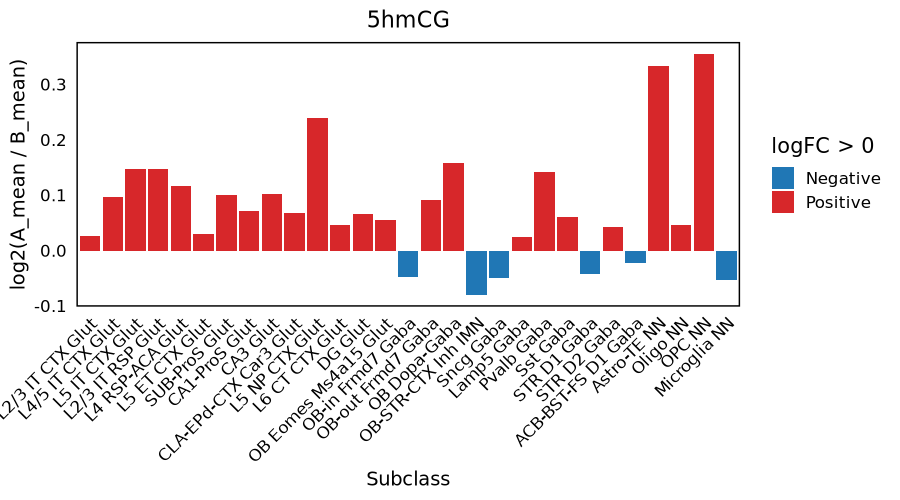

In [16]:
options(repr.plot.width = 9, repr.plot.height = 5, repr.plot.res = 100)
ggplot(mean_results, aes(x = Subclass, y = logFC, fill = logFC > 0)) +
  geom_col() +
  scale_fill_manual(values = c("FALSE" = "#2077B5", "TRUE" = "#D7272A"), 
                    labels = c("FALSE" = "Negative", "TRUE" = "Positive")) +
  theme_minimal(base_size = 15) +
  theme(
    panel.background = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title.x = element_text(color = "black", size = 14),
    axis.title.y = element_text(color = "black", size = 14),
    plot.title = element_text(size = 16, hjust = 0.5)
  ) +
  labs(x = "Subclass", y = "log2(A_mean / B_mean)", title = "5hmCG")

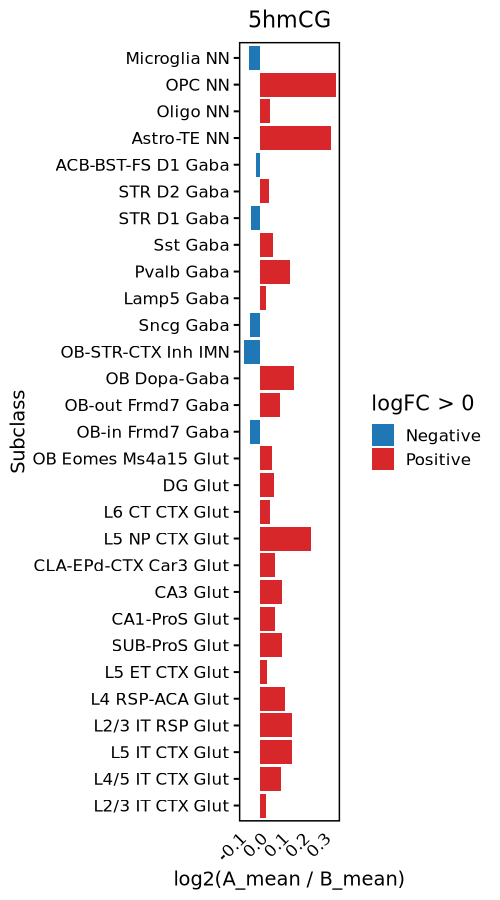

In [17]:
options(repr.plot.width = 5, repr.plot.height = 9, repr.plot.res = 100)
ggplot(mean_results, aes(y = Subclass, x = logFC, fill = logFC > 0)) + 
  geom_col() + 
  scale_fill_manual(values = c("FALSE" = "#2077B5", "TRUE" = "#D7272A"), 
                    labels = c("FALSE" = "Negative", "TRUE" = "Positive")) + 
  theme_minimal(base_size = 15) + 
  theme(
    panel.background = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1, 
                                linetype = "solid"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title.x = element_text(color = "black", size = 14),
    axis.title.y = element_text(color = "black", size = 14),
    plot.title = element_text(size = 16, hjust = 0.5),
    axis.ticks.y = element_line(color = "black")
  ) + 
  labs(x = "log2(A_mean / B_mean)", y = "Subclass", title = "5hmCG")


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_col()`).”


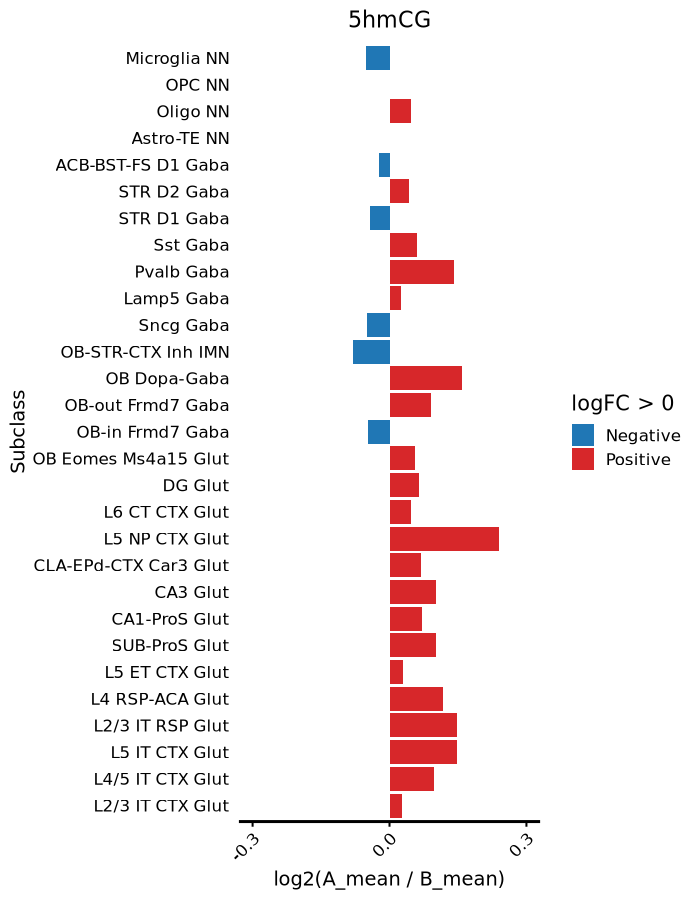

In [23]:
options(repr.plot.width = 7, repr.plot.height = 9, repr.plot.res = 100)
ggplot(mean_results, aes(y = Subclass, x = logFC, fill = logFC > 0)) + 
  geom_col() + 
  scale_fill_manual(values = c("FALSE" = "#2077B5", "TRUE" = "#D7272A"), 
                    labels = c("FALSE" = "Negative", "TRUE" = "Positive")) + 
  theme_minimal(base_size = 15) + 
  theme(
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    axis.line.y = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title.x = element_text(color = "black", size = 14),
    axis.title.y = element_text(color = "black", size = 14),
    plot.title = element_text(size = 16, hjust = 0.5),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  ) + 
  labs(x = "log2(A_mean / B_mean)", y = "Subclass", title = "5hmCG") + 
  scale_x_continuous(breaks = c(-0.3, 0, 0.3), limits = c(-0.3, 0.3))

In [ ]:
plot_AB_diff1 <- function(group,label) { # "5hmC_CG","5hmCG"

  data <- read.csv(sprintf("%s/03-%s_chrom100k_subclass_mean_dat_final_with_compartment.csv",indir,group), stringsAsFactors = FALSE, check.names = FALSE)
  
  label_columns <- grep("_compartment$", names(data), value = TRUE)

  mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

  for (label_col in label_columns) {

    main_col <- sub("_compartment$", "", label_col)
    
    if (main_col %in% names(data)) {

      mean_values <- data %>%
        filter(!is.na(.data[[label_col]])) %>%
        group_by(.data[[label_col]]) %>%
        summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
        pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

      A_mean <- mean_values[[paste0(main_col, "_A")]]
      B_mean <- mean_values[[paste0(main_col, "_B")]]

      subclass_results <- data.frame(
        Subclass = main_col,
        A_mean = A_mean,
        B_mean = B_mean,
        stringsAsFactors = FALSE
      )

      mean_results <- rbind(mean_results, subclass_results)
      
    } else {
      warning(paste("Main column not found for label column:", label_col))
    }
  }
  
#   mean_results$diff <- mean_results$A_mean - mean_results$B_mean
  mean_results <- mean_results %>%
  mutate(
    logFC = log2(A_mean / B_mean)
  )
  mean_results$Subclass <- factor(mean_results$Subclass, levels = rev(subclass))
  mean_results$color_flag <- ifelse(mean_results$logFC > 0, "positive", "negative")
  

  p1 <- ggplot(mean_results, aes(y = Subclass, x = logFC, fill = logFC > 0)) + 
  geom_col() + 
  scale_fill_manual(values = c("FALSE" = "#2077B5", "TRUE" = "#D7272A"), 
                    labels = c("FALSE" = "Negative", "TRUE" = "Positive")) + 
  theme_minimal(base_size = 15) + 
  theme(
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    axis.line.y = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title.x = element_text(color = "black", size = 14),
    axis.title.y = element_text(color = "black", size = 14),
    plot.title = element_text(size = 16, hjust = 0.5),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  ) + 
  labs(x = "log2(A_mean / B_mean)", y = "Subclass", title = label) + 
  scale_x_continuous(breaks = c(-0.3, 0, 0.3), limits = c(-0.3, 0.3))

#   p1 <- ggplot(mean_results, aes(x = Subclass, y = diff, fill = diff > 0)) +
#   geom_col() +
#   scale_fill_manual(values = c("FALSE" = "#2077B5", "TRUE" = "#D7272A"), 
#                     labels = c("FALSE" = "Negative", "TRUE" = "Positive")) +
#   scale_y_continuous(limits = c(-0.1, 0.1),
#                      labels = function(x) format(x, nsmall = 0, scientific = FALSE)) +  # 不使用科学计数法
#   theme_minimal(base_size = 15) +
#   theme(
#     panel.background = element_blank(),
#     panel.border = element_rect(color = "black", fill = NA, size = 1),
#     panel.grid.major = element_blank(),
#     panel.grid.minor = element_blank(),
#     axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 12),
#     axis.text.y = element_text(color = "black", size = 12),
#     axis.title.x = element_text(color = "black", size = 14),
#     axis.title.y = element_text(color = "black", size = 14),
#     plot.title = element_text(size = 16, hjust = 0.5)
#   ) +
#   labs(x = "Subclass", y = "Difference value (A-B)", title = label)
    
  return(p1)
}

In [25]:
P_hmCG <- plot_AB_diff1("5hmC_CG","5hmCG")

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_col()`).”


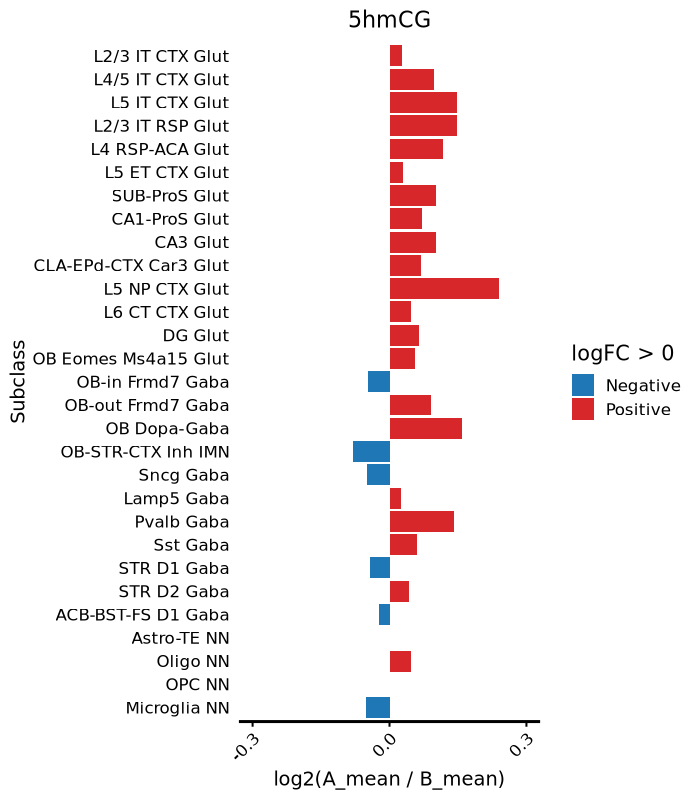

In [26]:
options(repr.plot.width = 7, repr.plot.height = 8, repr.plot.res = 100)
P_hmCG

In [ ]:
plot_AB_diff2 <- function(group,label) { # "5hmC_CG","5hmCG"

  data <- read.csv(sprintf("%s/03-%s_chrom100k_subclass_mean_dat_final_with_compartment.csv",indir,group), stringsAsFactors = FALSE, check.names = FALSE)
  
  label_columns <- grep("_compartment$", names(data), value = TRUE)

  mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

  for (label_col in label_columns) {

    main_col <- sub("_compartment$", "", label_col)
    
    if (main_col %in% names(data)) {

      mean_values <- data %>%
        filter(!is.na(.data[[label_col]])) %>%
        group_by(.data[[label_col]]) %>%
        summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
        pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

      A_mean <- mean_values[[paste0(main_col, "_A")]]
      B_mean <- mean_values[[paste0(main_col, "_B")]]

      subclass_results <- data.frame(
        Subclass = main_col,
        A_mean = A_mean,
        B_mean = B_mean,
        stringsAsFactors = FALSE
      )

      mean_results <- rbind(mean_results, subclass_results)
      
    } else {
      warning(paste("Main column not found for label column:", label_col))
    }
  }
  
#   mean_results$diff <- mean_results$A_mean - mean_results$B_mean
  mean_results <- mean_results %>%
  mutate(
    logFC = log2(A_mean / B_mean)
  )
  mean_results$Subclass <- factor(mean_results$Subclass, levels = rev(subclass))
  mean_results$color_flag <- ifelse(mean_results$logFC > 0, "positive", "negative")
  

  p1 <- ggplot(mean_results, aes(y = Subclass, x = logFC, fill = logFC > 0)) + 
  geom_col() + 
  scale_fill_manual(values = c("FALSE" = "#2077B5", "TRUE" = "#D7272A"), 
                    labels = c("FALSE" = "Negative", "TRUE" = "Positive")) + 
  theme_minimal(base_size = 15) + 
  theme(
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    axis.line.y = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title.x = element_text(color = "black", size = 14),
    axis.title.y = element_text(color = "black", size = 14),
    plot.title = element_text(size = 16, hjust = 0.5),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  ) + 
  labs(x = "log2(A_mean / B_mean)", y = "Subclass", title = label) + 
  scale_x_continuous(breaks = c(-0.3, 0, 0.3), limits = c(-0.3, 0.3))

#   p1 <- ggplot(mean_results, aes(x = Subclass, y = diff, fill = diff > 0)) +
#   geom_col() +
#   scale_fill_manual(values = c("FALSE" = "#2077B5", "TRUE" = "#D7272A"), 
#                     labels = c("FALSE" = "Negative", "TRUE" = "Positive")) +
#   scale_y_continuous(limits = c(-0.01, 0.01),
#                      labels = function(x) format(x, nsmall = 0, scientific = FALSE)) +  # 不使用科学计数法
#   theme_minimal(base_size = 15) +
#   theme(
#     panel.background = element_blank(),
#     panel.border = element_rect(color = "black", fill = NA, size = 1),
#     panel.grid.major = element_blank(),
#     panel.grid.minor = element_blank(),
#     axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 12),
#     axis.text.y = element_text(color = "black", size = 12),
#     axis.title.x = element_text(color = "black", size = 14),
#     axis.title.y = element_text(color = "black", size = 14),
#     plot.title = element_text(size = 16, hjust = 0.5)
#   ) +
#   labs(x = "Subclass", y = "Difference value (A-B)", title = label)
    
  return(p1)
}

In [28]:
P_hmCH <- plot_AB_diff2("5hmC_CH","5hmCH")

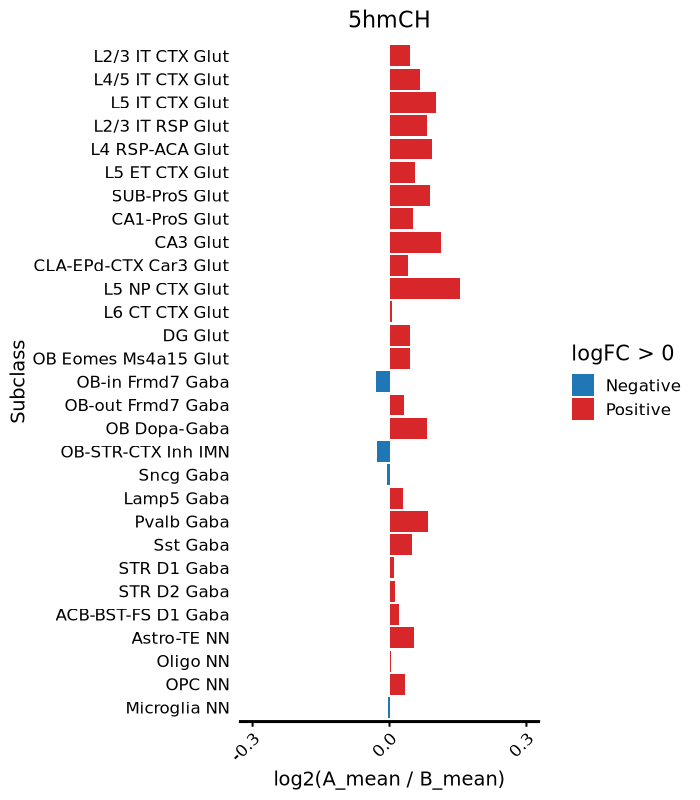

In [29]:
options(repr.plot.width = 7, repr.plot.height = 8, repr.plot.res = 100)
P_hmCH

In [30]:
P_mCG <- plot_AB_diff1("5mC_CG","5mCG+5hmCG")

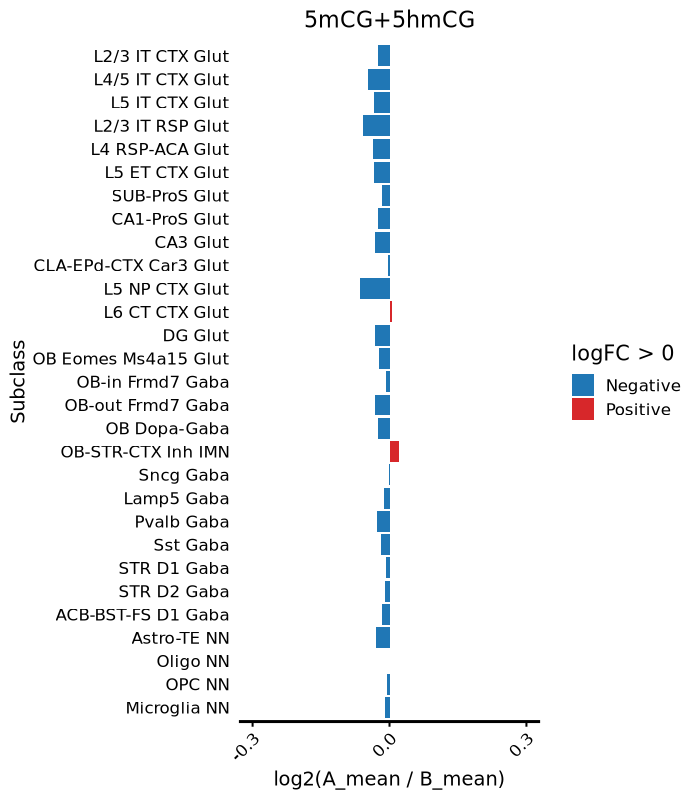

In [31]:
options(repr.plot.width = 7, repr.plot.height = 8, repr.plot.res = 100)
P_mCG

In [32]:
P_mCH <- plot_AB_diff2("5mC_CH","5mCH+5hmCH")

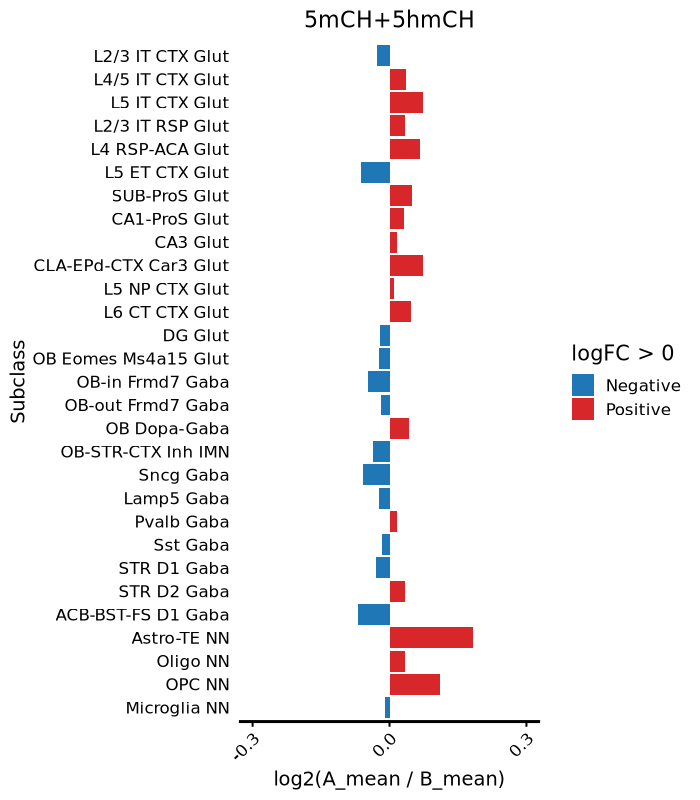

In [33]:
options(repr.plot.width = 7, repr.plot.height = 8, repr.plot.res = 100)
P_mCH

In [ ]:
plot_AB_diff3 <- function(group,label) { # "5hmC_CG","5hmCG"

  data <- read.csv(sprintf("%s/03-%s_chrom100k_subclass_mean_dat_final_with_compartment.csv",indir,group), stringsAsFactors = FALSE, check.names = FALSE)
  
  check_and_fix_first_column_name <- function(data) {
      if (is.na(names(data)[1]) || names(data)[1] == "") {
          names(data)[1] <- "chrom100k"
          print("第一列的列名为空，已更改为 'chrom100k'")
      } else {
          print("第一列的列名为: ", names(data)[1])
      }
      return(data)
  }
  
  data <- check_and_fix_first_column_name(data)
  
  label_columns <- grep("_compartment$", names(data), value = TRUE)

  mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

  for (label_col in label_columns) {

    main_col <- sub("_compartment$", "", label_col)
    
    if (main_col %in% names(data)) {

      mean_values <- data %>%
        filter(!is.na(.data[[label_col]])) %>%
        group_by(.data[[label_col]]) %>%
        summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
        pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

      A_mean <- mean_values[[paste0(main_col, "_A")]]
      B_mean <- mean_values[[paste0(main_col, "_B")]]

      subclass_results <- data.frame(
        Subclass = main_col,
        A_mean = A_mean,
        B_mean = B_mean,
        stringsAsFactors = FALSE
      )

      mean_results <- rbind(mean_results, subclass_results)
      
    } else {
      warning(paste("Main column not found for label column:", label_col))
    }
  }
  
#   mean_results$diff <- mean_results$A_mean - mean_results$B_mean
  mean_results <- mean_results %>%
  mutate(
    logFC = log2(A_mean / B_mean)
  )
  mean_results$Subclass <- factor(mean_results$Subclass, levels = rev(subclass))
  mean_results$color_flag <- ifelse(mean_results$logFC > 0, "positive", "negative")
  
  p1 <- ggplot(mean_results, aes(y = Subclass, x = logFC, fill = logFC > 0)) + 
  geom_col() + 
  scale_fill_manual(values = c("FALSE" = "#2077B5", "TRUE" = "#D7272A"), 
                    labels = c("FALSE" = "Negative", "TRUE" = "Positive")) + 
  theme_minimal(base_size = 15) + 
  theme(
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    axis.line.y = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title.x = element_text(color = "black", size = 14),
    axis.title.y = element_text(color = "black", size = 14),
    plot.title = element_text(size = 16, hjust = 0.5),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  ) + 
  labs(x = "log2(A_mean / B_mean)", y = "Subclass", title = label) + 
  scale_x_continuous(breaks = c(-0.3, 0, 0.3), limits = c(-0.3, 0.3))

#   p1 <- ggplot(mean_results, aes(x = Subclass, y = diff, fill = diff > 0)) +
#   geom_col() +
#   scale_fill_manual(values = c("FALSE" = "#2077B5", "TRUE" = "#D7272A"), 
#                     labels = c("FALSE" = "Negative", "TRUE" = "Positive")) +
#   scale_y_continuous(limits = c(-0.1, 0.1),
#                      labels = function(x) format(x, nsmall = 0, scientific = FALSE)) +  # 不使用科学计数法
#   theme_minimal(base_size = 15) +
#   theme(
#     panel.background = element_blank(),
#     panel.border = element_rect(color = "black", fill = NA, size = 1),
#     panel.grid.major = element_blank(),
#     panel.grid.minor = element_blank(),
#     axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 12),
#     axis.text.y = element_text(color = "black", size = 12),
#     axis.title.x = element_text(color = "black", size = 14),
#     axis.title.y = element_text(color = "black", size = 14),
#     plot.title = element_text(size = 16, hjust = 0.5)
#   ) +
#   labs(x = "Subclass", y = "Difference value (A-B)", title = label)
    
  return(p1)
}

In [35]:
P_true5mC_CG <- plot_AB_diff3("true5mC_CG","5mCG")

[1] "第一列的列名为空，已更改为 'chrom100k'"


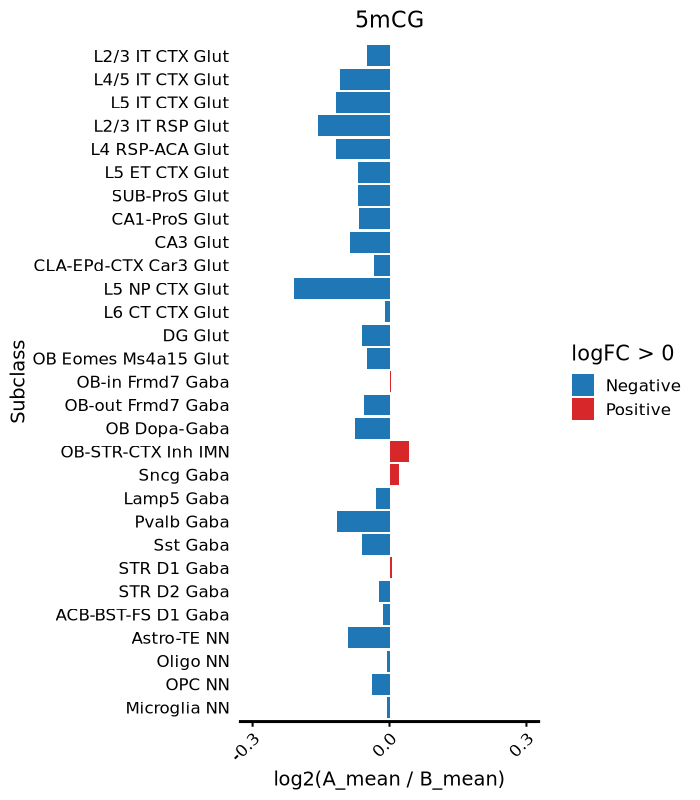

In [36]:
options(repr.plot.width = 7, repr.plot.height = 8, repr.plot.res = 100)
P_true5mC_CG

In [ ]:
plot_AB_diff4 <- function(group,label) { # "5hmC_CG","5hmCG"

  data <- read.csv(sprintf("%s/03-%s_chrom100k_subclass_mean_dat_final_with_compartment.csv",indir,group), stringsAsFactors = FALSE, check.names = FALSE)
  
  check_and_fix_first_column_name <- function(data) {
      if (is.na(names(data)[1]) || names(data)[1] == "") {
          names(data)[1] <- "chrom100k"
          print("第一列的列名为空，已更改为 'chrom100k'")
      } else {
          print("第一列的列名为: ", names(data)[1])
      }
      return(data)
  }
  
  data <- check_and_fix_first_column_name(data)
  
  label_columns <- grep("_compartment$", names(data), value = TRUE)

  mean_results <- data.frame(Subclass = character(), A_mean = numeric(), B_mean = numeric(), stringsAsFactors = FALSE)

  for (label_col in label_columns) {

    main_col <- sub("_compartment$", "", label_col)
    
    if (main_col %in% names(data)) {

      mean_values <- data %>%
        filter(!is.na(.data[[label_col]])) %>%
        group_by(.data[[label_col]]) %>%
        summarise(mean_value = mean(.data[[main_col]], na.rm = TRUE), .groups = 'drop') %>%
        pivot_wider(names_from = .data[[label_col]], values_from = mean_value, names_prefix = paste0(main_col, "_"))

      A_mean <- mean_values[[paste0(main_col, "_A")]]
      B_mean <- mean_values[[paste0(main_col, "_B")]]

      subclass_results <- data.frame(
        Subclass = main_col,
        A_mean = A_mean,
        B_mean = B_mean,
        stringsAsFactors = FALSE
      )

      mean_results <- rbind(mean_results, subclass_results)
      
    } else {
      warning(paste("Main column not found for label column:", label_col))
    }
  }
  
#   mean_results$diff <- mean_results$A_mean - mean_results$B_mean
  mean_results <- mean_results %>%
  mutate(
    logFC = log2(A_mean / B_mean)
  )
  mean_results$Subclass <- factor(mean_results$Subclass, levels = rev(subclass))
  mean_results$color_flag <- ifelse(mean_results$logFC > 0, "positive", "negative")
  
  p1 <- ggplot(mean_results, aes(y = Subclass, x = logFC, fill = logFC > 0)) + 
  geom_col() + 
  scale_fill_manual(values = c("FALSE" = "#2077B5", "TRUE" = "#D7272A"), 
                    labels = c("FALSE" = "Negative", "TRUE" = "Positive")) + 
  theme_minimal(base_size = 15) + 
  theme(
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 1),
    axis.line.y = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 12),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title.x = element_text(color = "black", size = 14),
    axis.title.y = element_text(color = "black", size = 14),
    plot.title = element_text(size = 16, hjust = 0.5),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_line(color = "black")
  ) + 
  labs(x = "log2(A_mean / B_mean)", y = "Subclass", title = label) + 
  scale_x_continuous(breaks = c(-0.3, 0, 0.3), limits = c(-0.3, 0.3))

#   p1 <- ggplot(mean_results, aes(x = Subclass, y = diff, fill = diff > 0)) +
#   geom_col() +
#   scale_fill_manual(values = c("FALSE" = "#2077B5", "TRUE" = "#D7272A"), 
#                     labels = c("FALSE" = "Negative", "TRUE" = "Positive")) +
#   scale_y_continuous(limits = c(-0.01, 0.01),
#                      labels = function(x) format(x, nsmall = 0, scientific = FALSE)) +  # 不使用科学计数法
#   theme_minimal(base_size = 15) +
#   theme(
#     panel.background = element_blank(),
#     panel.border = element_rect(color = "black", fill = NA, size = 1),
#     panel.grid.major = element_blank(),
#     panel.grid.minor = element_blank(),
#     axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 12),
#     axis.text.y = element_text(color = "black", size = 12),
#     axis.title.x = element_text(color = "black", size = 14),
#     axis.title.y = element_text(color = "black", size = 14),
#     plot.title = element_text(size = 16, hjust = 0.5)
#   ) +
#   labs(x = "Subclass", y = "Difference value (A-B)", title = label)
    
  return(p1)
}

In [38]:
P_true5mC_CH <- plot_AB_diff4("true5mC_CH","5mCH")

[1] "第一列的列名为空，已更改为 'chrom100k'"


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_col()`).”


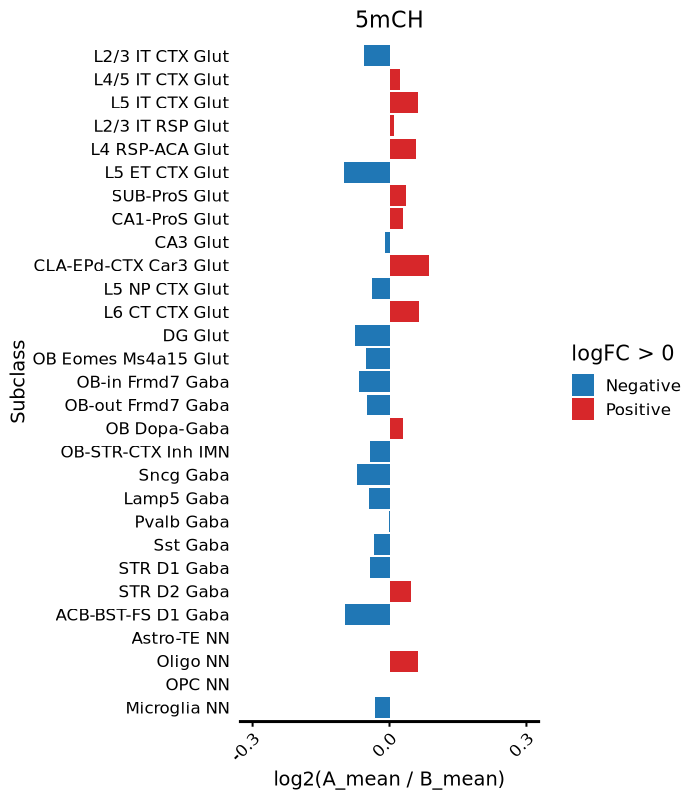

In [39]:
options(repr.plot.width = 7, repr.plot.height = 8, repr.plot.res = 100)
P_true5mC_CH

In [40]:
library(gridExtra)
library(ggplot2)


载入程辑包：‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [41]:
g1 <- arrangeGrob(P_hmCG, heights = unit(8, "inches"), widths = unit(7, "inches"))
g2 <- arrangeGrob(P_true5mC_CG, heights = unit(8, "inches"), widths = unit(7, "inches"))
g3 <- arrangeGrob(P_mCG, heights = unit(8, "inches"), widths = unit(7, "inches"))
g4 <- arrangeGrob(P_hmCH, heights = unit(8, "inches"), widths = unit(7, "inches"))
g5 <- arrangeGrob(P_true5mC_CH, heights = unit(8, "inches"), widths = unit(7, "inches"))
g6 <- arrangeGrob(P_mCH, heights = unit(8, "inches"), widths = unit(7, "inches"))

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_col()`).”


In [44]:
combined_plot <- arrangeGrob(g3, g1, g2, g6, g4, g5, ncol = 6, nrow = 1)

In [ ]:
ggsave("../../../output/01.Young_Mouse/05-AB_compartment/07-Subclass_AB_compartment_DNA_methyl_log2FC_20250207.pdf", combined_plot, width = 42, height = 8)